# Reading NetCDF File for Oregon Location 1

This notebook demonstrates how to:
1. Load the Oregon Location 1 NetCDF ocean dataset (`CMVoregonloc1.nc`)
2. Convert it into a Pandas DataFrame and calculate current velocity (`speed` in cm/s) and `direction` (in degrees)
3. Display summary statistics and visualize distributions for the entire dataset
4. Plot the monthly distributions of speed and direction across all 48 months in the dataset
5. Subset the dataset into years (`year1`, `year2`, `year3`, and an 11-month `year4`) starting from the initial timestamp
6. Display summary statistics and visualize distributions for individual years

In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Load the NetCDF file
We use `xarray.open_dataset` to load the `CMVoregonloc1.nc` file efficiently.

In [3]:
nc_file = 'CMVoregonloc1.nc'
ds = xr.open_dataset(nc_file)
ds

<xarray.Dataset> Size: 8MB
Dimensions:    (time: 34345, depth: 1, latitude: 7, longitude: 4)
Coordinates:
  * time       (time) datetime64[ns] 275kB 2022-07-04T12:00:00 ... 2026-06-04...
  * depth      (depth) float32 4B 0.494
  * latitude   (latitude) float32 28B 45.67 45.75 45.83 45.92 46.0 46.08 46.17
  * longitude  (longitude) float32 16B -124.2 -124.2 -124.1 -124.0
Data variables:
    uo         (time, depth, latitude, longitude) float32 4MB ...
    vo         (time, depth, latitude, longitude) float32 4MB ...
Attributes:
    Conventions:       CF-1.11
    title:             hourly mean fields from Global Ocean Physics Analysis ...
    institution:       Mercator Ocean International
    producer:          CMEMS - Global Monitoring and Forecasting Centre
    source:            MOI GLO12
    credit:            E.U. Copernicus Marine Service Information (CMEMS)
    contact:           https://marine.copernicus.eu/contact
    references:        http://marine.copernicus.eu
    subset:source:     ARCO data downloaded from the Marine Data Store using ...
    subset:productId:  GLOBAL_ANALYSISFORECAST_PHY_001_024
    subset:datasetId:  cmems_mod_glo_phy_anfc_0.083deg_PT1H-m_202406
    subset:date:       2026-06-03T21:34:33.506Z

### 2. Convert to DataFrame and Calculate Velocity/Direction
We convert the dataset to a Pandas DataFrame, reset its index, and immediately compute the current speed (scaled to **cm/s**) and direction (in degrees relative to North).

In [4]:
# Convert to DataFrame
df = ds.to_dataframe().reset_index()

# 1. Calculate Vector Magnitude (Sea Water Speed) in m/s
df['speed'] = np.sqrt(df['uo']**2 + df['vo']**2)

# 2. Convert Speed to cm/s for clean integer ticks on x-axis
df['speed_cms'] = df['speed'] * 100

# 3. Calculate Vector Direction in Degrees (Oceanographic convention: 0° = North, 90° = East)
sea_water_dir = np.degrees(np.arctan2(df['uo'], df['vo']))
df['direction'] = (sea_water_dir + 360) % 360  # Ensure all values are 0-360°

print("DataFrame loaded and vector calculations complete!")
df[['time', 'latitude', 'longitude', 'uo', 'vo', 'speed_cms', 'direction']].head()

DataFrame loaded and vector calculations complete!


,time,latitude,longitude,uo,vo,speed_cms,direction
0,2022-07-04 12:00:00,45.666668,-124.250000,-0.083070,-0.268676,28.122505,197.180801
1,2022-07-04 12:00:00,45.666668,-124.166664,-0.095966,-0.524013,53.272839,190.377991
2,2022-07-04 12:00:00,45.666668,-124.083328,-0.072212,-0.545397,55.015671,187.542267
3,2022-07-04 12:00:00,45.666668,-124.000000,-0.065525,-0.492825,49.716175,187.573517
4,2022-07-04 12:00:00,45.750000,-124.250000,-0.099817,-0.230111,25.082737,203.450104


### 3. Inspect DataFrame Info & Summary Statistics (Entire Dataset)
View structural info and statistical summaries for the entire Oregon dataset.

In [5]:
print("--- DataFrame Info ---")
df.info()

print("\n--- Summary Statistics (Entire Dataset) ---")
display(df[['uo', 'vo', 'speed_cms', 'direction']].describe())

--- DataFrame Info ---
<class 'pandas.DataFrame'>
RangeIndex: 961660 entries, 0 to 961659
Data columns (total 9 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   time       961660 non-null  datetime64[ns]
 1   depth      961660 non-null  float32       
 2   latitude   961660 non-null  float32       
 3   longitude  961660 non-null  float32       
 4   uo         961660 non-null  float32       
 5   vo         961660 non-null  float32       
 6   speed      961660 non-null  float32       
 7   speed_cms  961660 non-null  float32       
 8   direction  961660 non-null  float32       
dtypes: datetime64[ns](1), float32(8)
memory usage: 36.7 MB

--- Summary Statistics (Entire Dataset) ---


,uo,vo,speed_cms,direction
count,961660.000000,961660.000000,961660.000000,961660.000000
mean,-0.010654,-0.026149,20.783354,189.759064
std,0.098957,0.217610,12.144493,103.193611
min,-0.767998,-0.834337,0.016070,0.000427
25%,-0.073183,-0.176022,11.546877,130.360382
50%,-0.009605,-0.033909,18.702642,185.295273
75%,0.053099,0.119667,27.936547,272.331726
max,0.503149,0.919621,91.997917,359.999786


### 4. Visualize Distributions (Entire Dataset)
Plot the speed and direction histograms for the entire dataset.

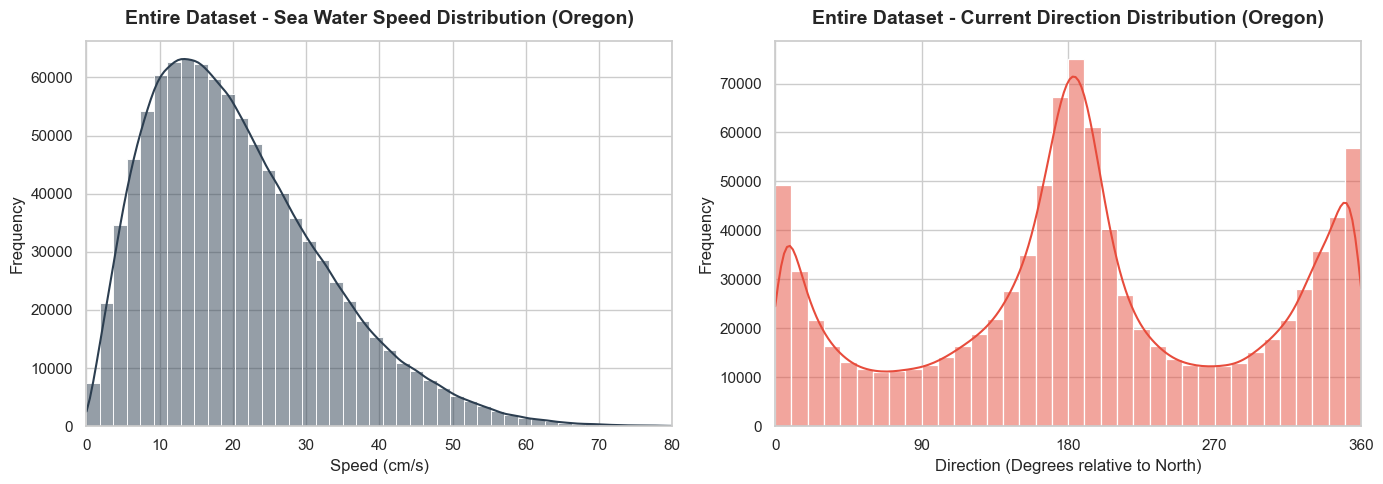

In [6]:
# Set visual style
sns.set_theme(style="whitegrid")

# Create side-by-side plots for the entire dataset
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Speed Histogram
sns.histplot(data=df, x='speed_cms', bins=50, kde=True, ax=axes[0], color='#2c3e50')
axes[0].set_title('Entire Dataset - Sea Water Speed Distribution (Oregon)', fontsize=14, fontweight='bold', pad=12)
axes[0].set_xlabel('Speed (cm/s)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_xlim(0, 80)
axes[0].set_xticks([0, 10, 20, 30, 40, 50, 60, 70, 80])

# Direction Histogram
sns.histplot(data=df, x='direction', bins=36, kde=True, ax=axes[1], color='#e74c3c')
axes[1].set_title('Entire Dataset - Current Direction Distribution (Oregon)', fontsize=14, fontweight='bold', pad=12)
axes[1].set_xlabel('Direction (Degrees relative to North)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_xlim(0, 360)
axes[1].set_xticks([0, 90, 180, 270, 360])

plt.tight_layout()
plt.show()

### 5. Monthly Distribution of Speed and Direction (Entire Dataset)
Box plots of current speed and direction grouped by calendar month to show seasonal trends chronologically.

C:\Users\chris\AppData\Local\Temp\ipykernel_14068\811448220.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='year_month', y='speed_cms', ax=axes[0], palette='crest', order=sorted_months)
C:\Users\chris\AppData\Local\Temp\ipykernel_14068\811448220.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
C:\Users\chris\AppData\Local\Temp\ipykernel_14068\811448220.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='year_month', y='direction', ax=axes[1], palette='flare', order=sorted_months)
C:\Users\chris\AppDa

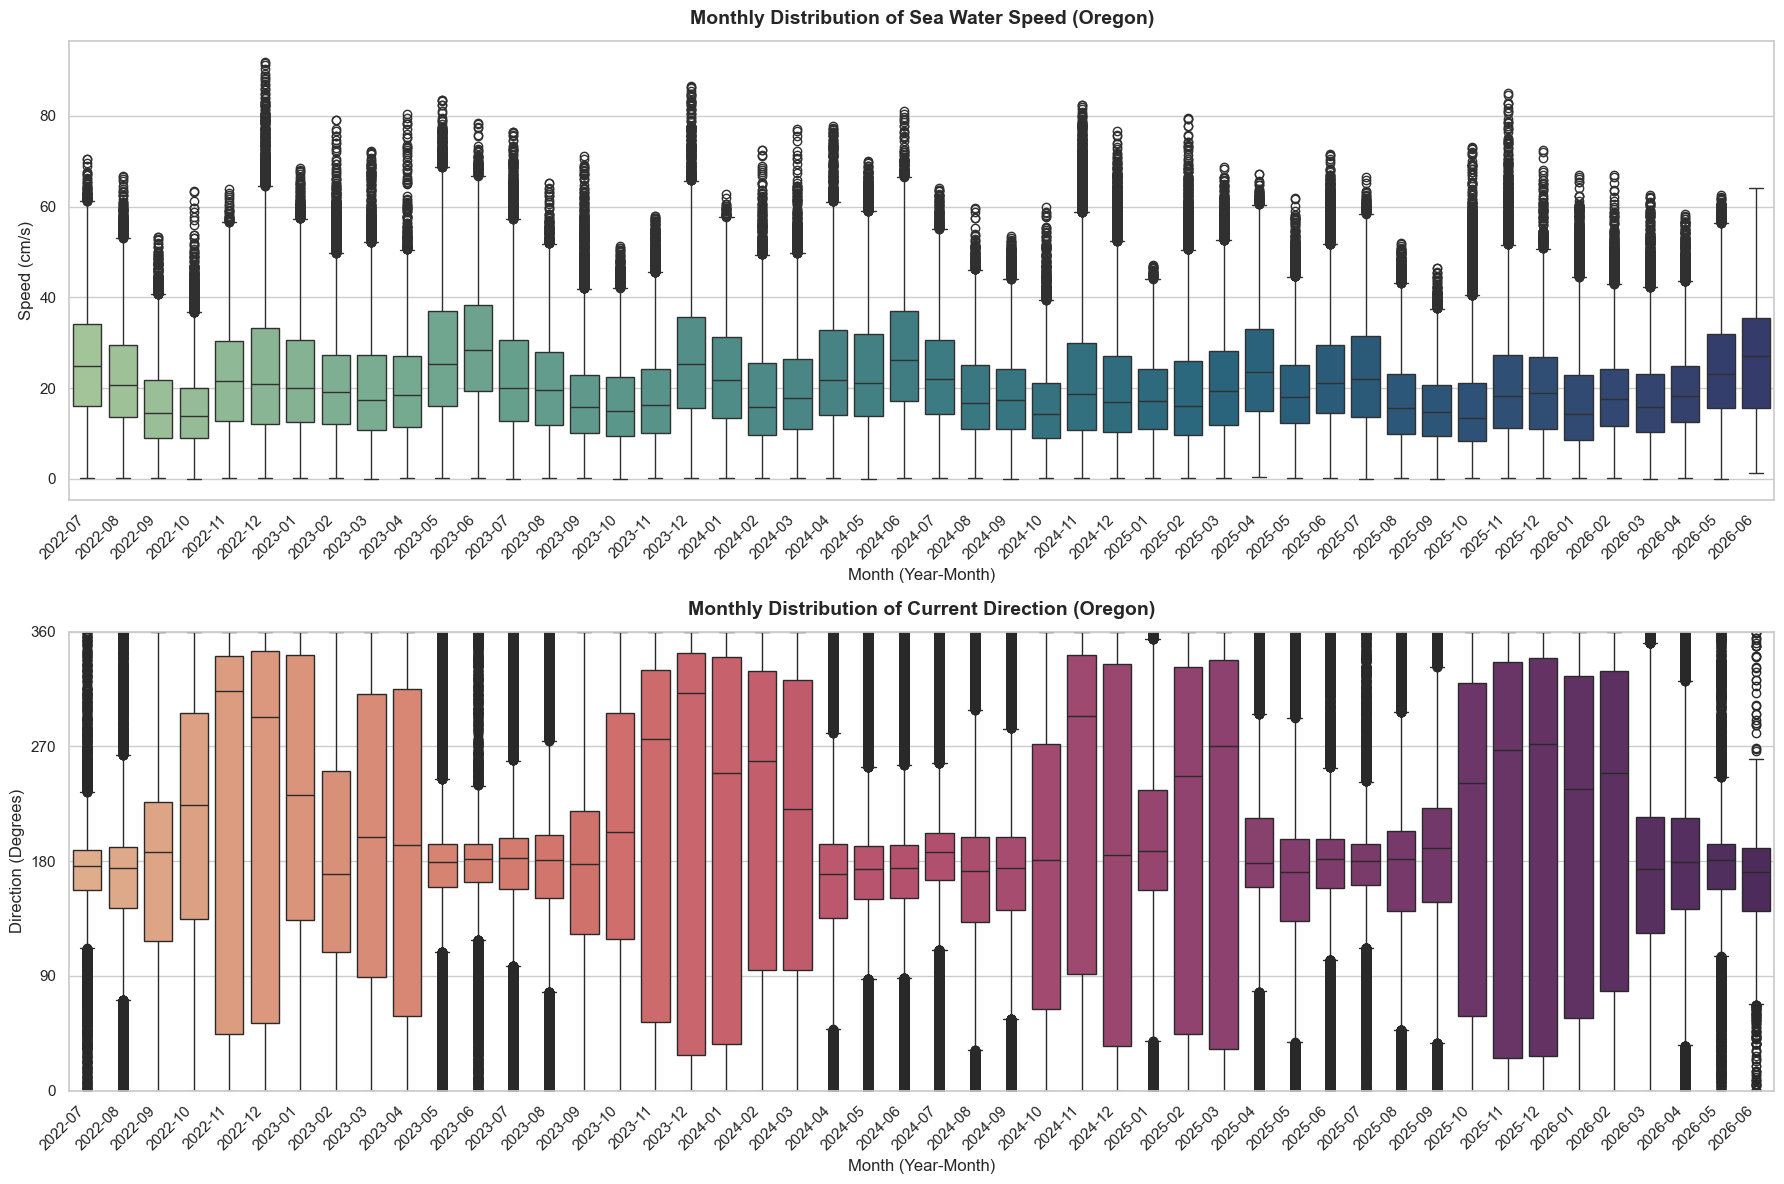

In [7]:
# Create a sorted Year-Month string column for chronological grouping
df['year_month'] = df['time'].dt.strftime('%Y-%m')
sorted_months = sorted(df['year_month'].unique())

# Setup figure with 2 rows (Speed & Direction)
fig, axes = plt.subplots(2, 1, figsize=(18, 12))

# 1. Box plot for Speed (cm/s)
sns.boxplot(data=df, x='year_month', y='speed_cms', ax=axes[0], palette='crest', order=sorted_months)
axes[0].set_title('Monthly Distribution of Sea Water Speed (Oregon)', fontsize=14, fontweight='bold', pad=12)
axes[0].set_xlabel('Month (Year-Month)', fontsize=12)
axes[0].set_ylabel('Speed (cm/s)', fontsize=12)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

# 2. Box plot for Direction (Degrees)
sns.boxplot(data=df, x='year_month', y='direction', ax=axes[1], palette='flare', order=sorted_months)
axes[1].set_title('Monthly Distribution of Current Direction (Oregon)', fontsize=14, fontweight='bold', pad=12)
axes[1].set_xlabel('Month (Year-Month)', fontsize=12)
axes[1].set_ylabel('Direction (Degrees)', fontsize=12)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].set_ylim(0, 360)
axes[1].set_yticks([0, 90, 180, 270, 360])

plt.tight_layout()
plt.show()

### 6. Subset the Dataset into Years
Divide the dataset into chronological 12-month periods from the start timestamp:
- **`year1`**: July 4, 2022 – July 4, 2023 (12 months)
- **`year2`**: July 4, 2023 – July 4, 2024 (12 months)
- **`year3`**: July 4, 2024 – July 4, 2025 (12 months)
- **`year4`**: July 4, 2025 – June 4, 2026 (remaining 11 months)

In [8]:
# Ensure time column is datetime objects
df['time'] = pd.to_datetime(df['time'])

# Define start date of the dataset
start_date = df['time'].min()

# Define 12-month boundary offsets
y1_end = start_date + pd.DateOffset(years=1)
y2_end = start_date + pd.DateOffset(years=2)
y3_end = start_date + pd.DateOffset(years=3)

# Subset into distinct copies
year1 = df[(df['time'] >= start_date) & (df['time'] < y1_end)].copy()
year2 = df[(df['time'] >= y1_end) & (df['time'] < y2_end)].copy()
year3 = df[(df['time'] >= y2_end) & (df['time'] < y3_end)].copy()
year4 = df[(df['time'] >= y3_end)].copy()  # Spans the remaining 11 months

# Print range and shapes
years_dfs = [year1, year2, year3, year4]
for i, y_df in enumerate(years_dfs, 1):
    label = f"Year {i}" if i < 4 else "Year 4 (11 months)"
    print(f"{label}: {y_df['time'].min()} to {y_df['time'].max()} | Shape: {y_df.shape}")

Year 1: 2022-07-04 12:00:00 to 2023-07-04 11:00:00 | Shape: (245280, 10)
Year 2: 2023-07-04 12:00:00 to 2024-07-04 11:00:00 | Shape: (245952, 10)
Year 3: 2024-07-04 12:00:00 to 2025-07-04 11:00:00 | Shape: (245280, 10)
Year 4 (11 months): 2025-07-04 12:00:00 to 2026-06-04 12:00:00 | Shape: (225148, 10)


### 7. Summary Statistics by Year
Descriptive statistics for each subsetted year.

In [9]:
for i, y_df in enumerate(years_dfs, 1):
    label = f"Year {i}" if i < 4 else "Year 4 (11-Month remaining)"
    print(f"\n{'='*20} {label} Summary Statistics {'='*20}")
    display(y_df[['uo', 'vo', 'speed_cms', 'direction']].describe())


==================== Year 1 Summary Statistics ====================


,uo,vo,speed_cms,direction
count,245280.000000,245280.000000,245280.000000,245280.000000
mean,-0.011774,-0.032112,22.260498,191.945740
std,0.102314,0.234065,12.988939,103.349205
min,-0.767998,-0.834337,0.026648,0.001099
25%,-0.075164,-0.195394,12.291915,134.792343
50%,-0.011335,-0.035339,20.040185,185.540337
75%,0.053078,0.129057,30.148286,279.123955
max,0.481530,0.919621,91.997917,359.999786



==================== Year 2 Summary Statistics ====================


,uo,vo,speed_cms,direction
count,245952.000000,245952.000000,245952.000000,245952.000000
mean,-0.009361,-0.020414,21.479143,191.440247
std,0.103013,0.224886,12.471680,104.671974
min,-0.533293,-0.808308,0.048056,0.000427
25%,-0.074547,-0.174442,11.942953,130.311256
50%,-0.008767,-0.025708,19.345178,185.043297
75%,0.057050,0.132154,29.071867,284.076454
max,0.503149,0.864391,86.712158,359.999176



==================== Year 3 Summary Statistics ====================


,uo,vo,speed_cms,direction
count,245280.000000,245280.000000,245280.000000,245280.000000
mean,-0.008257,-0.031067,20.237144,186.845016
std,0.094749,0.211231,11.693871,101.122627
min,-0.541765,-0.712035,0.058235,0.000427
25%,-0.068182,-0.181173,11.403047,130.393234
50%,-0.006006,-0.046422,18.340819,183.385063
75%,0.054681,0.108185,26.963421,254.751312
max,0.451600,0.823129,82.472649,359.999115



==================== Year 4 (11-Month remaining) Summary Statistics ====================


,uo,vo,speed_cms,direction
count,225148.000000,225148.000000,225148.000000,225148.000000
mean,-0.013457,-0.020560,19.009106,188.714996
std,0.095037,0.196439,10.995202,103.540787
min,-0.581385,-0.650479,0.016070,0.001068
25%,-0.074771,-0.154027,10.647424,124.984116
50%,-0.012555,-0.028088,17.158876,187.474609
75%,0.047311,0.110545,25.466086,268.581696
max,0.425754,0.828015,85.033806,359.999664


### 8. Visualizing Year-by-Year Distributions with Histograms
Compare speed and direction distributions across all 4 years.

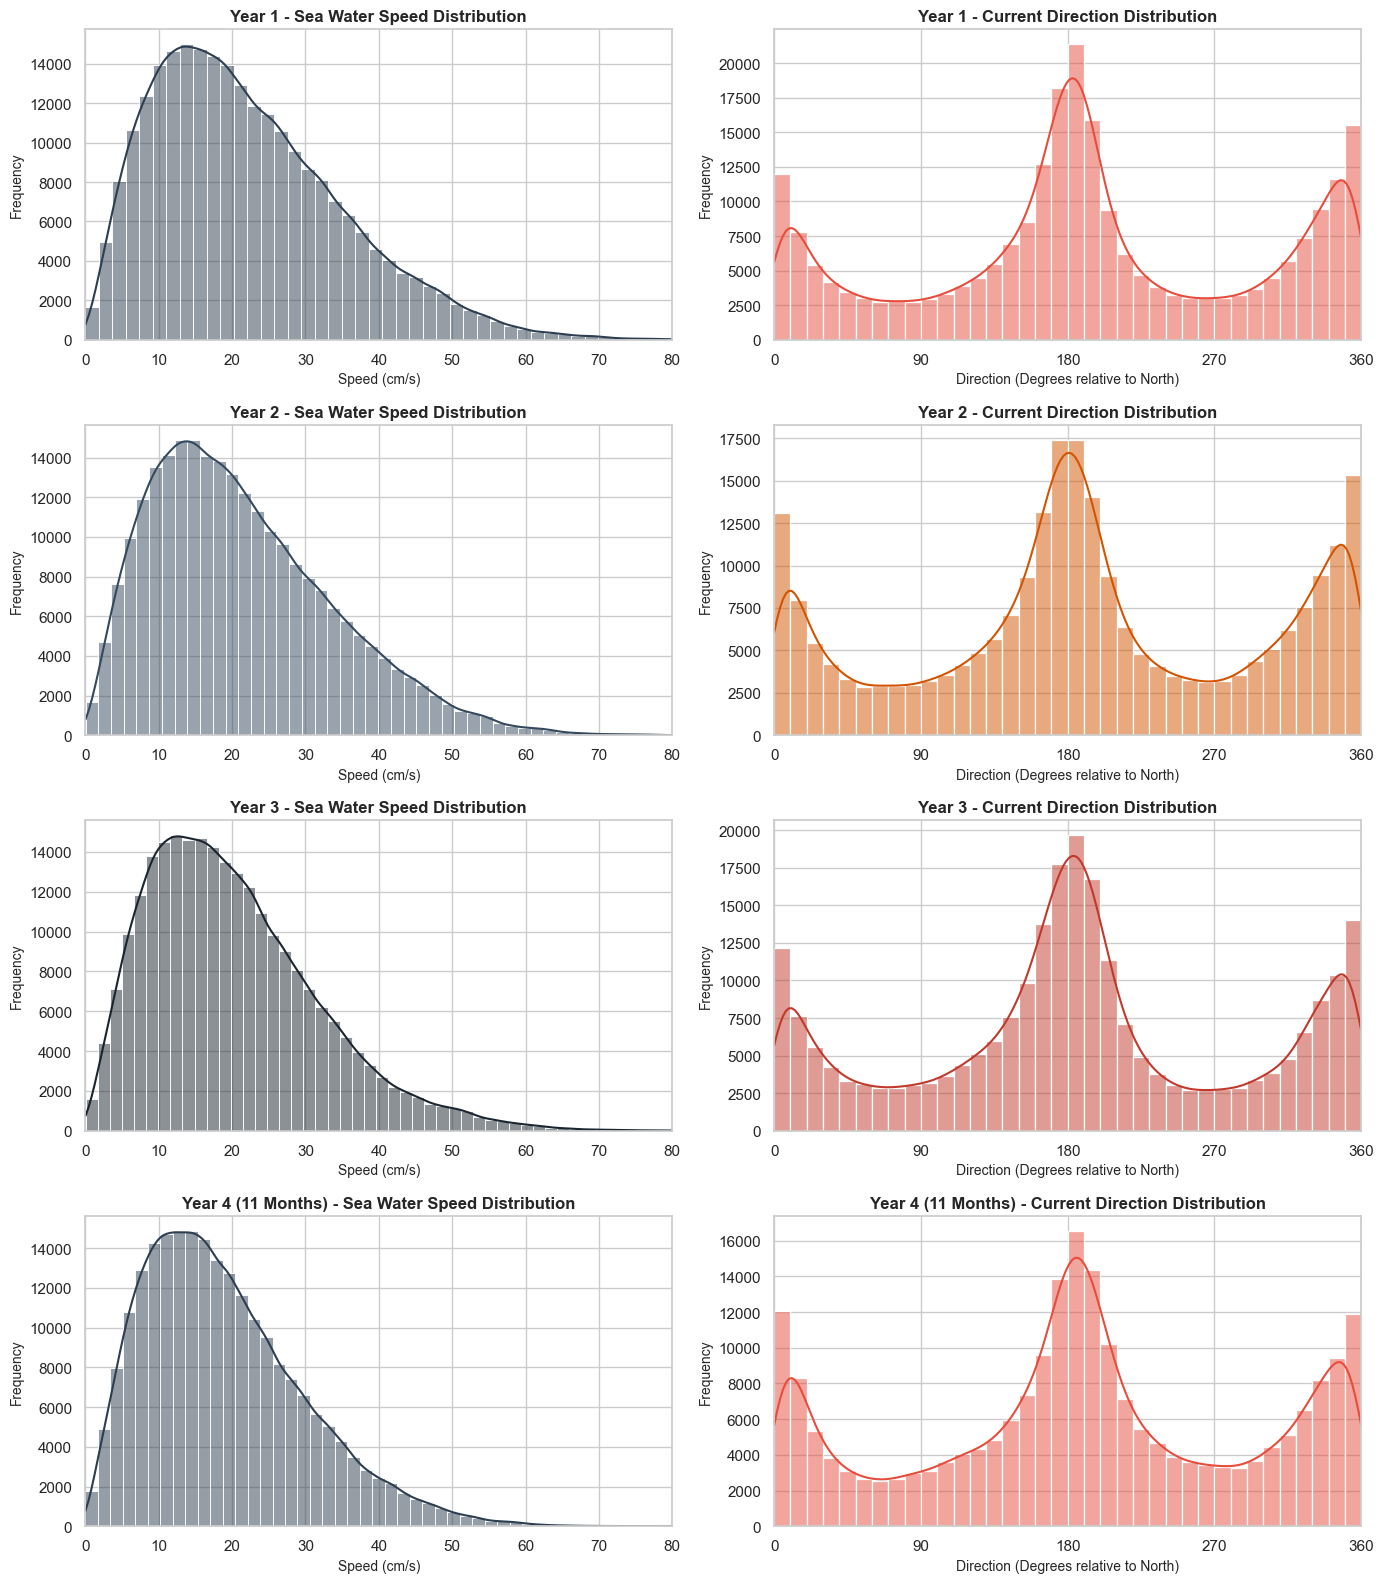

In [10]:
# Set visual style
sns.set_theme(style="whitegrid")

# Create a 4x2 grid of subplots (4 years, 2 metrics)
fig, axes = plt.subplots(4, 2, figsize=(14, 16))

colors_speed = ['#2c3e50', '#34495e', '#1a252f', '#2c3e50']
colors_dir = ['#e74c3c', '#d35400', '#c0392b', '#e74c3c']

for i, y_df in enumerate(years_dfs):
    year_label = f"Year {i+1}" if i < 3 else "Year 4 (11 Months)"
    
    # Speed Histogram (Left Column)
    sns.histplot(data=y_df, x='speed_cms', bins=50, kde=True, ax=axes[i, 0], color=colors_speed[i])
    axes[i, 0].set_title(f'{year_label} - Sea Water Speed Distribution', fontsize=12, fontweight='bold')
    axes[i, 0].set_xlabel('Speed (cm/s)', fontsize=10)
    axes[i, 0].set_ylabel('Frequency', fontsize=10)
    axes[i, 0].set_xlim(0, 80)
    axes[i, 0].set_xticks([0, 10, 20, 30, 40, 50, 60, 70, 80])
    
    # Direction Histogram (Right Column)
    sns.histplot(data=y_df, x='direction', bins=36, kde=True, ax=axes[i, 1], color=colors_dir[i])
    axes[i, 1].set_title(f'{year_label} - Current Direction Distribution', fontsize=12, fontweight='bold')
    axes[i, 1].set_xlabel('Direction (Degrees relative to North)', fontsize=10)
    axes[i, 1].set_ylabel('Frequency', fontsize=10)
    axes[i, 1].set_xlim(0, 360)
    axes[i, 1].set_xticks([0, 90, 180, 270, 360])

plt.tight_layout()
plt.show()

### 9. Dataset Duration Verification
Calculates total temporal coverage.

In [11]:
from dateutil.relativedelta import relativedelta

start_date = pd.to_datetime(df['time'].min())
end_date = pd.to_datetime(df['time'].max())
diff = relativedelta(end_date, start_date)

print(f"Start Date: {start_date}")
print(f"End Date:   {end_date}")
print(f"Total Duration: {diff.years} years, {diff.months} months, and {diff.days} days")

Start Date: 2022-07-04 12:00:00
End Date:   2026-06-04 12:00:00
Total Duration: 3 years, 11 months, and 0 days
